# Employee Attrition Analysis & Prediction

## Project Overview

This project analyzes employee attrition patterns and develops a machine-learning model to predict whether an employee is likely to leave the organization.

### Objectives

- Analyze employee attrition patterns
- Identify factors associated with employee turnover
- Visualize important HR insights
- Build a Logistic Regression classification model
- Evaluate model performance
- Provide actionable HR recommendations

### Dataset

The dataset contains **1,500 employee records** and **17 original features**.

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
import random

random.seed(42)
np.random.seed(42)

n = 1500

departments = ["Sales", "Research & Development", "Human Resources", "Finance", "IT"]
job_roles = [
    "Sales Executive",
    "Research Scientist",
    "Laboratory Technician",
    "Manager",
    "Human Resources",
    "Software Engineer",
    "Accountant"
]
education_fields = ["Life Sciences", "Medical", "Marketing", "Technical Degree", "Human Resources", "Finance"]

data = []

for i in range(n):
    age = np.random.randint(22, 61)
    department = random.choice(departments)
    job_role = random.choice(job_roles)

    monthly_income = np.random.randint(2500, 18001)
    years_at_company = np.random.randint(0, min(31, age - 21))
    years_in_current_role = np.random.randint(0, min(16, years_at_company + 1))

    job_satisfaction = np.random.randint(1, 5)
    work_life_balance = np.random.randint(1, 5)
    job_involvement = np.random.randint(1, 5)

    overtime = random.choice(["Yes", "No"])
    business_travel = random.choice(["Rarely", "Frequently", "Travel_Rarely"])
    education_field = random.choice(education_fields)

    distance_from_home = np.random.randint(1, 31)
    num_companies_worked = np.random.randint(0, 10)
    training_times_last_year = np.random.randint(0, 7)

    # Create realistic attrition patterns
    risk = 0

    if overtime == "Yes":
        risk += 2

    if job_satisfaction <= 2:
        risk += 2

    if work_life_balance <= 2:
        risk += 1

    if monthly_income < 4500:
        risk += 1

    if years_at_company <= 2:
        risk += 2

    if distance_from_home > 20:
        risk += 1

    if age < 30:
        risk += 1

    if job_involvement <= 2:
        risk += 1

    # Convert risk into probability
    probability = min(0.08 + (risk * 0.09), 0.85)

    attrition = "Yes" if random.random() < probability else "No"

    data.append({
        "EmployeeID": i + 1,
        "Age": age,
        "Department": department,
        "JobRole": job_role,
        "EducationField": education_field,
        "MonthlyIncome": monthly_income,
        "YearsAtCompany": years_at_company,
        "YearsInCurrentRole": years_in_current_role,
        "JobSatisfaction": job_satisfaction,
        "WorkLifeBalance": work_life_balance,
        "JobInvolvement": job_involvement,
        "OverTime": overtime,
        "BusinessTravel": business_travel,
        "DistanceFromHome": distance_from_home,
        "NumCompaniesWorked": num_companies_worked,
        "TrainingTimesLastYear": training_times_last_year,
        "Attrition": attrition
    })

employee_df = pd.DataFrame(data)

# Save dataset
employee_df.to_csv("employee_attrition.csv", index=False)

print("Employee dataset created successfully!")
print("Number of employees:", len(employee_df))
print("Number of columns:", len(employee_df.columns))
print("Attrition rate:", round(
    (employee_df["Attrition"] == "Yes").mean() * 100, 2
), "%")

Employee dataset created successfully!
Number of employees: 1500
Number of columns: 17
Attrition rate: 44.13 %


In [7]:
employee_df.head(10)

,EmployeeID,Age,Department,JobRole,EducationField,MonthlyIncome,YearsAtCompany,YearsInCurrentRole,JobSatisfaction,WorkLifeBalance,JobInvolvement,OverTime,BusinessTravel,DistanceFromHome,NumCompaniesWorked,TrainingTimesLastYear,Attrition
0,1,60,Sales,Sales Executive,Medical,3360,14,10,4,1,1,No,Rarely,7,9,2,Yes
1,2,44,Sales,Software Engineer,Technical Degree,6926,10,7,1,4,4,Yes,Travel_Rarely,24,2,5,Yes
2,3,23,Sales,Research Scientist,Human Resources,13083,1,1,2,2,4,Yes,Travel_Rarely,28,4,0,Yes
3,4,33,Research & Development,Software Engineer,Technical Degree,5885,5,4,4,1,1,No,Rarely,27,9,3,No
4,5,37,Sales,Accountant,Technical Degree,12498,13,13,3,2,3,Yes,Travel_Rarely,12,6,3,Yes
5,6,24,Research & Development,Research Scientist,Life Sciences,6056,2,2,1,1,3,No,Rarely,18,3,0,Yes
6,7,35,Human Resources,Accountant,Marketing,10933,9,8,2,1,2,No,Travel_Rarely,20,6,3,No
7,8,29,Finance,Human Resources,Life Sciences,14706,2,1,1,4,2,Yes,Frequently,8,3,1,Yes
8,9,27,IT,Accountant,Medical,13305,1,1,2,1,3,No,Travel_Rarely,18,9,3,No
9,10,55,Sales,Software Engineer,Life Sciences,6797,29,3,2,3,4,Yes,Frequently,15,7,5,No


In [8]:
print("Dataset Shape:", employee_df.shape)

print("\nMissing Values:")
print(employee_df.isnull().sum())

print("\nData Types:")
print(employee_df.dtypes)

Dataset Shape: (1500, 17)

Missing Values:
EmployeeID               0
Age                      0
Department               0
JobRole                  0
EducationField           0
MonthlyIncome            0
YearsAtCompany           0
YearsInCurrentRole       0
JobSatisfaction          0
WorkLifeBalance          0
JobInvolvement           0
OverTime                 0
BusinessTravel           0
DistanceFromHome         0
NumCompaniesWorked       0
TrainingTimesLastYear    0
Attrition                0
dtype: int64

Data Types:
EmployeeID               int64
Age                      int64
Department                 str
JobRole                    str
EducationField             str
MonthlyIncome            int64
YearsAtCompany           int64
YearsInCurrentRole       int64
JobSatisfaction          int64
WorkLifeBalance          int64
JobInvolvement           int64
OverTime                   str
BusinessTravel             str
DistanceFromHome         int64
NumCompaniesWorked       int64
Trainin

In [9]:
employee_df.describe()

,EmployeeID,Age,MonthlyIncome,YearsAtCompany,YearsInCurrentRole,JobSatisfaction,WorkLifeBalance,JobInvolvement,DistanceFromHome,NumCompaniesWorked,TrainingTimesLastYear
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,750.500000,41.115333,10178.279333,9.027333,3.875333,2.484667,2.446667,2.490667,15.939333,4.449333,3.01000
std,433.157015,11.025020,4524.801749,7.867307,4.215800,1.137231,1.124277,1.136709,8.646473,2.881834,1.99647
min,1.000000,22.000000,2501.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000
25%,375.750000,32.000000,6193.250000,2.000000,0.000000,1.000000,1.000000,1.000000,9.000000,2.000000,1.00000
50%,750.500000,41.000000,10182.000000,7.000000,2.000000,2.000000,2.000000,2.000000,16.000000,4.000000,3.00000
75%,1125.250000,50.250000,14092.500000,14.000000,6.000000,4.000000,3.000000,4.000000,24.000000,7.000000,5.00000
max,1500.000000,60.000000,17993.000000,30.000000,15.000000,4.000000,4.000000,4.000000,30.000000,9.000000,6.00000


In [10]:
attrition_counts = employee_df["Attrition"].value_counts()

print("Attrition Counts:")
print(attrition_counts)

print("\nAttrition Percentage:")
print((employee_df["Attrition"].value_counts(normalize=True) * 100).round(2))

Attrition Counts:
Attrition
No     838
Yes    662
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     55.87
Yes    44.13
Name: proportion, dtype: float64


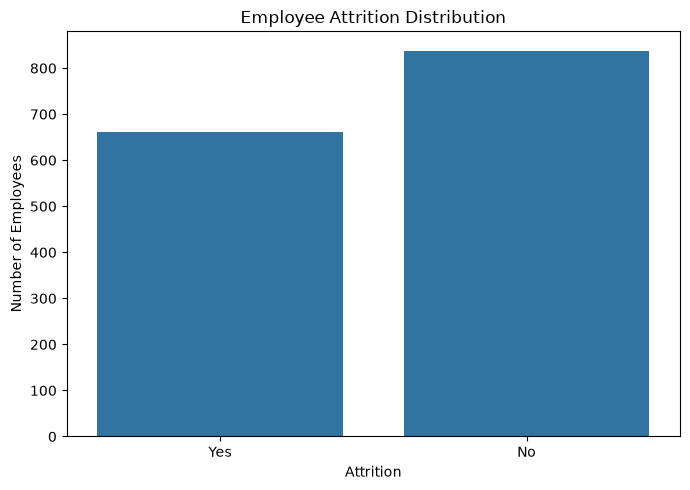

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(data=employee_df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [12]:
department_attrition = pd.crosstab(
    employee_df["Department"],
    employee_df["Attrition"],
    normalize="index"
) * 100

department_attrition = department_attrition.sort_values(
    "Yes",
    ascending=False
)

department_attrition

Attrition,No,Yes
Department,,
Human Resources,52.733119,47.266881
IT,52.922078,47.077922
Research & Development,54.266212,45.733788
Sales,59.574468,40.425532
Finance,60.130719,39.869281


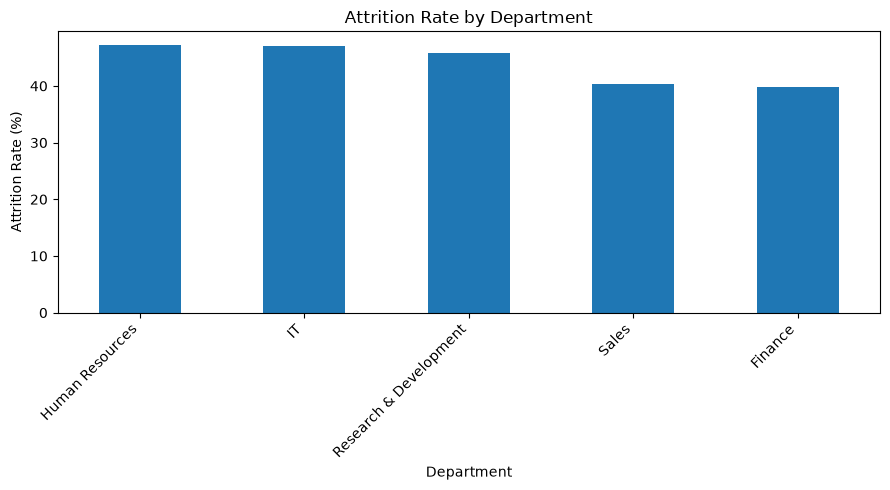

In [13]:
plt.figure(figsize=(9, 5))

department_attrition["Yes"].plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [14]:
age_groups = pd.cut(
    employee_df["Age"],
    bins=[20, 30, 40, 50, 60],
    labels=["21-30", "31-40", "41-50", "51-60"]
)

age_attrition = pd.crosstab(
    age_groups,
    employee_df["Attrition"],
    normalize="index"
) * 100

age_attrition

Attrition,No,Yes
Age,,
21-30,38.557994,61.442006
31-40,57.739558,42.260442
41-50,60.150376,39.849624
51-60,64.000000,36.000000


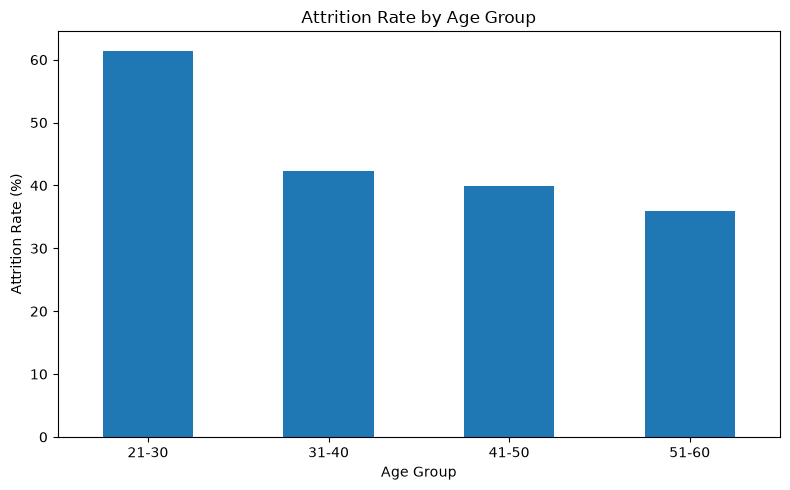

In [15]:
plt.figure(figsize=(8, 5))

age_attrition["Yes"].plot(kind="bar")

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
income_groups = pd.qcut(
    employee_df["MonthlyIncome"],
    q=4,
    labels=["Low Income", "Lower-Middle", "Upper-Middle", "High Income"]
)

income_attrition = pd.crosstab(
    income_groups,
    employee_df["Attrition"],
    normalize="index"
) * 100

income_attrition

Attrition,No,Yes
MonthlyIncome,,
Low Income,49.600000,50.400000
Lower-Middle,56.533333,43.466667
Upper-Middle,62.400000,37.600000
High Income,54.933333,45.066667


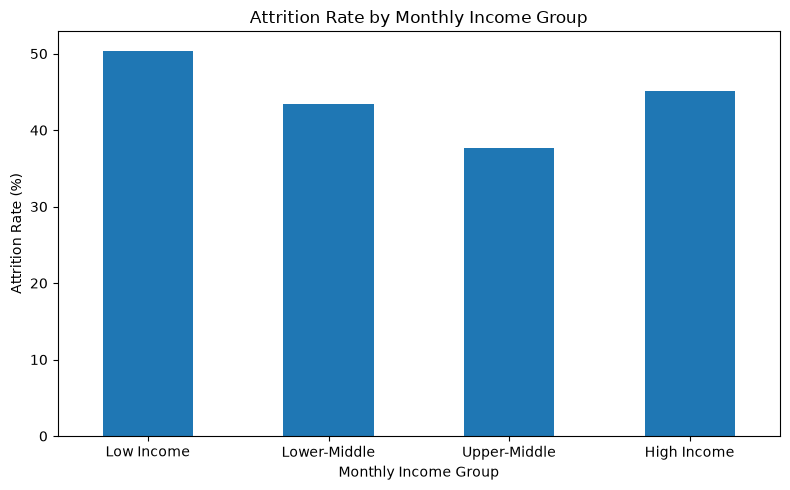

In [17]:
plt.figure(figsize=(8, 5))

income_attrition["Yes"].plot(kind="bar")

plt.title("Attrition Rate by Monthly Income Group")
plt.xlabel("Monthly Income Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
overtime_attrition = pd.crosstab(
    employee_df["OverTime"],
    employee_df["Attrition"],
    normalize="index"
) * 100

overtime_attrition

Attrition,No,Yes
OverTime,,
No,63.522013,36.477987
Yes,47.234043,52.765957


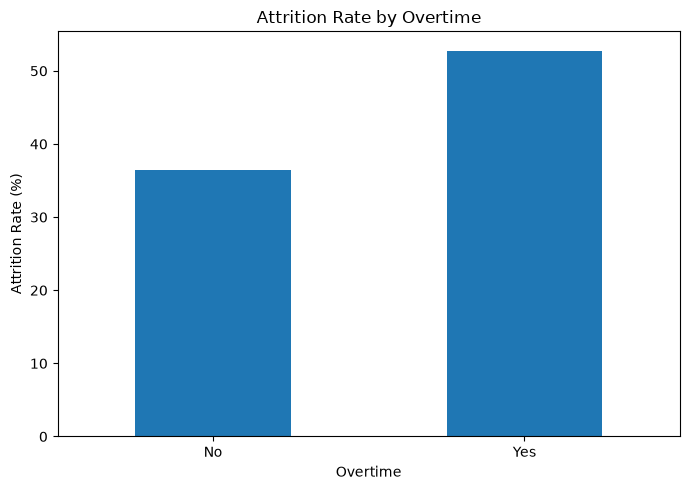

In [19]:
plt.figure(figsize=(7, 5))

overtime_attrition["Yes"].plot(kind="bar")

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [20]:
satisfaction_attrition = pd.crosstab(
    employee_df["JobSatisfaction"],
    employee_df["Attrition"],
    normalize="index"
) * 100

satisfaction_attrition

Attrition,No,Yes
JobSatisfaction,,
1,48.232323,51.767677
2,46.321526,53.678474
3,66.381766,33.618234
4,63.212435,36.787565


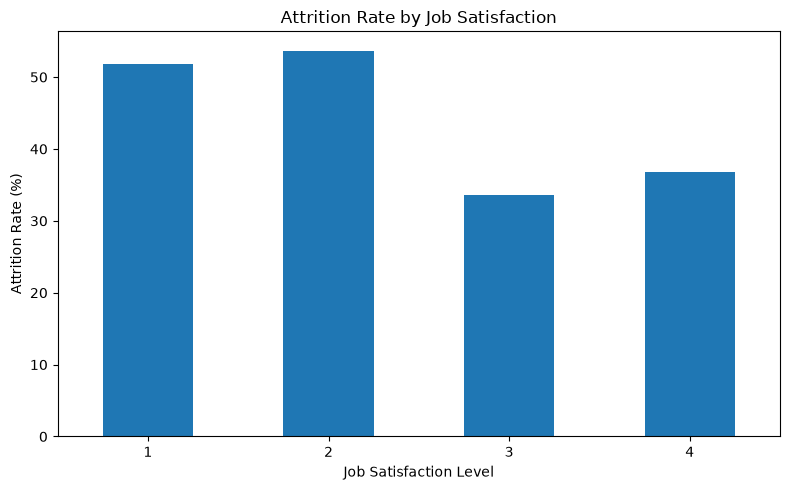

In [21]:
plt.figure(figsize=(8, 5))

satisfaction_attrition["Yes"].plot(kind="bar")

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [22]:
worklife_attrition = pd.crosstab(
    employee_df["WorkLifeBalance"],
    employee_df["Attrition"],
    normalize="index"
) * 100

worklife_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,53.300733,46.699267
2,49.863014,50.136986
3,60.589812,39.410188
4,60.056657,39.943343


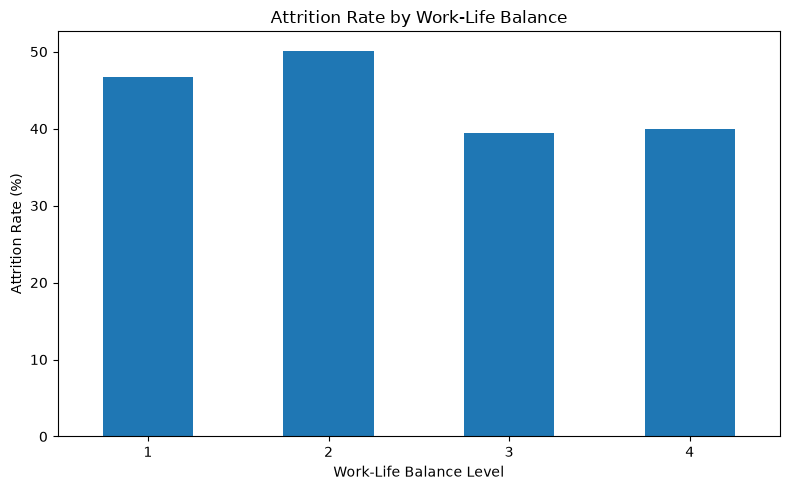

In [23]:
plt.figure(figsize=(8, 5))

worklife_attrition["Yes"].plot(kind="bar")

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
# Create a copy for machine learning
ml_df = employee_df.copy()

# Convert Attrition to 0 and 1
ml_df["Attrition"] = ml_df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

# Convert categorical columns into numerical columns
categorical_columns = [
    "Department",
    "JobRole",
    "EducationField",
    "OverTime",
    "BusinessTravel"
]

ml_df = pd.get_dummies(
    ml_df,
    columns=categorical_columns,
    drop_first=True
)

print("Machine learning dataset created!")
print("Rows:", ml_df.shape[0])
print("Columns:", ml_df.shape[1])

Machine learning dataset created!
Rows: 1500
Columns: 30


In [25]:
X = ml_df.drop("Attrition", axis=1)
y = ml_df["Attrition"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (1500, 29)
Target shape: (1500,)

Target distribution:
Attrition
0    838
1    662
Name: count, dtype: int64


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 1200
Testing samples: 300

Training target distribution:
Attrition
0    670
1    530
Name: count, dtype: int64

Testing target distribution:
Attrition
0    168
1    132
Name: count, dtype: int64


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Training data shape: (1200, 29)
Testing data shape: (300, 29)


In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [29]:
y_pred = model.predict(X_test_scaled)

print("Predictions created successfully!")
print("Number of predictions:", len(y_pred))

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions created successfully!
Number of predictions: 300

First 20 predictions:
[1 0 0 0 1 1 1 0 0 1 1 0 0 1 0 0 0 0 1 0]


In [30]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Left"]
))

Model Accuracy: 62.33 %

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.65      0.70      0.68       168
        Left       0.58      0.52      0.55       132

    accuracy                           0.62       300
   macro avg       0.62      0.61      0.61       300
weighted avg       0.62      0.62      0.62       300



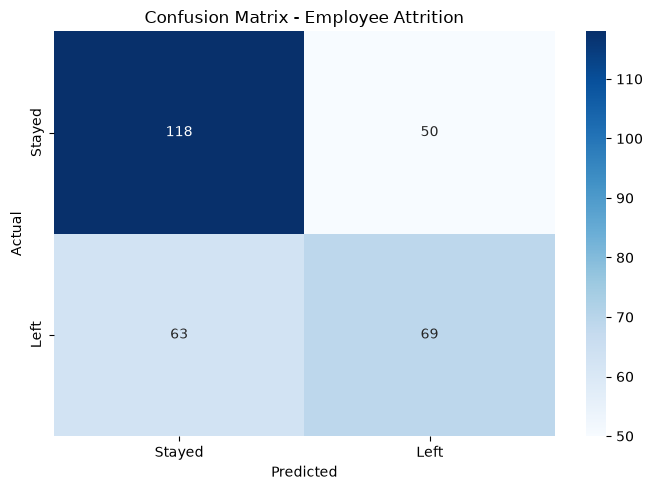

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Left"],
    yticklabels=["Stayed", "Left"]
)

plt.title("Confusion Matrix - Employee Attrition")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [33]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Importance": np.abs(model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Importance
26,OverTime_Yes,0.399625,0.399625
5,JobSatisfaction,-0.350853,0.350853
1,Age,-0.288877,0.288877
4,YearsInCurrentRole,-0.255599,0.255599
6,WorkLifeBalance,-0.193978,0.193978
7,JobInvolvement,-0.179526,0.179526
8,DistanceFromHome,0.153043,0.153043
25,EducationField_Technical Degree,0.151594,0.151594
20,JobRole_Software Engineer,0.122665,0.122665
11,Department_Human Resources,0.106669,0.106669


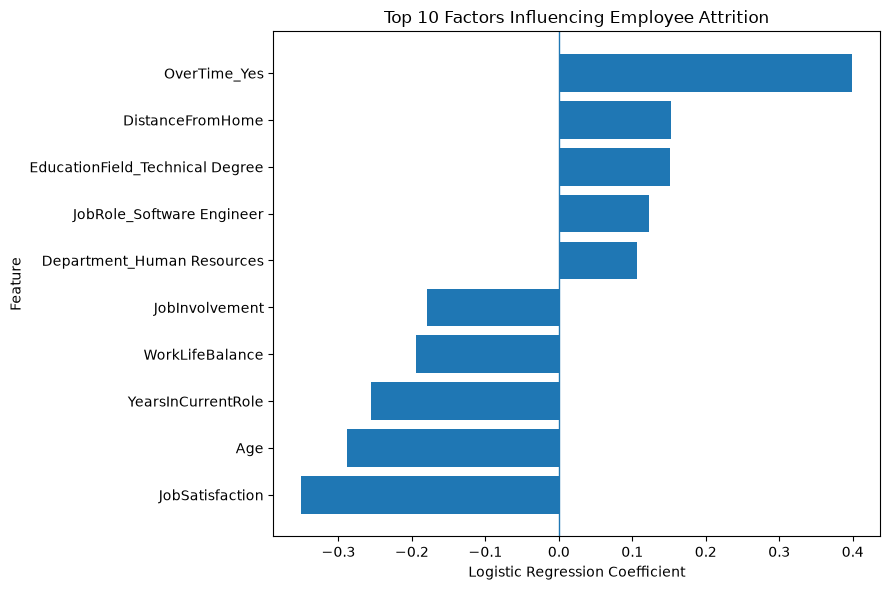

In [34]:
top_features = feature_importance.head(10).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.title("Top 10 Factors Influencing Employee Attrition")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Conclusion

## Key Findings

- The overall employee attrition rate in the dataset is **44.13%**.
- Employees working **overtime** showed a higher attrition rate of approximately **52.76%**, compared with **36.48%** for employees without overtime.
- Employees with lower **job satisfaction** levels showed higher attrition rates.
- Employees in the **21–30 age group** had the highest attrition rate at approximately **61.44%**.
- **Human Resources** and **IT** showed the highest department-level attrition rates.
- Employees with lower **work-life balance** levels generally showed higher attrition.
- The Logistic Regression model achieved an accuracy of **62.33%** on the test dataset.
- The most influential model features included **OverTime, Job Satisfaction, Age, Years in Current Role, Work-Life Balance, Job Involvement, and Distance From Home**.

## Business Recommendations

1. Reduce excessive overtime and monitor employees who frequently work overtime.
2. Improve employee engagement and job satisfaction through feedback and recognition programs.
3. Provide career-development and internal-growth opportunities to reduce employee turnover.
4. Monitor younger employees who show higher attrition risk.
5. Promote better work-life balance through workload management and flexible working practices.
6. Use attrition-risk analysis to identify employees who may require additional HR support.

## Machine Learning Outcome

A Logistic Regression classification model was developed to predict employee attrition.

The model achieved:

- **Accuracy:** 62.33%
- **Precision for employees who left:** 58%
- **Recall for employees who left:** 52%
- **F1-score for employees who left:** 55%

The model provides a useful baseline for identifying employees at risk of attrition. Future improvements could include testing additional machine-learning algorithms and tuning model parameters.

## Project Outcome

This project demonstrates how Python, Pandas, data visualization, exploratory data analysis, and machine learning can be used to understand employee attrition and generate actionable HR insights.